# 143 Precipitation Timelapse animation

This notebook demonstrates how to generate the timelapse animation of [IMERG precipitation dataset](https://developers.google.com/earth-engine/datasets/catalog/NASA_GPM_L3_IMERG_V06). In the animation, you can add map elements such as, title of map, north arrow, map scale, colorbar etc.

In [ ]:
# !pip install .
# !pip install cartopy scipy

In [ ]:
import geemap
import ee

ee.Authenticate()
ee.Initialize(project="ee-popovicradovan02")

print(geemap.__version__)

0.35.3


In [ ]:
m = geemap.Map(center=(44, 21), zoom=7)
m

Map(center=[44, 21], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI(chil…

In [ ]:
# Extract the required country boundary, in this case Serbia

countries = ee.FeatureCollection("FAO/GAUL/2015/level0")

kosovo = countries.filter(ee.Filter.eq("ADM0_NAME", "Kosovo"))
serbia = countries.filter(ee.Filter.eq("ADM0_NAME", "Serbia"))

serbia_geometry = serbia.geometry()
kosovo_geometry = kosovo.geometry()

# UNION geometrija (ISPRAVNO)
serbia_with_kosovo_geometry = serbia_geometry.union(kosovo_geometry)

print("Kosovo je Srbija po deklarativnoj preambuli Ustava iz 2006.")

# Load IMERG precipitation data
date = ee.Date("2014-05-09")
precipitation_collection = (
    ee.ImageCollection("NASA/GPM_L3/IMERG_V06")
    .filterDate(date, date.advance(1, "day"))
    .select("precipitationCal")
)


# Define a function to mask out precipitation less than 0.5 mm/hr
def mask_less_ppt(collection):
    masked_collection = collection.map(lambda image: image.updateMask(image.gte(0.5)))
    return masked_collection


# Mask out precipitation less than 0.5 mm/hr
masked_imerg_collection = mask_less_ppt(precipitation_collection)

# add indonesia boundary to map
style = {"color": "000ffff0", "width": 2, "lineType": "solid", "fillColor": "00000000"}
m.addLayer(serbia.style(**style), {}, "serbia + kosovo")


# Define visualization parameters
palette = [
    "000096",
    "0064ff",
    "00b4ff",
    "33db80",
    "9beb4a",
    "ffeb00",
    "ffb300",
    "ff6400",
    "eb1e00",
    "af0000",
]
vis_params = {
    "min": 0,
    "max": 50,
    "bands": "precipitationCal",
    "palette": ["000096", "0064ff", "00b4ff", "eb1e00", "af0000"],
}

# # Add the precipitation data to the map
# m.addLayer(masked_imerg_collection, vis_params, 'Precipitation (IMERG)')
# m

Kosovo je Srbija po deklarativnoj preambuli Ustava iz 2006.


In [ ]:
# clip the precipitation data to the Indonesia boundary
clipped_imerg_collection = masked_imerg_collection.map(
    lambda image: image.clip(serbia_with_kosovo_geometry)
)

# Get the number of images in the clipped collection
clipped_imerg_collection.size().getInfo()

48

In [ ]:
# get bounding box of indonesia
serbia_bbox = serbia_with_kosovo_geometry.bounds()
serbia_bbox

ee.Geometry({
  "functionInvocationValue": {
    "functionName": "Geometry.bounds",
    "arguments": {
      "geometry": {
        "functionInvocationValue": {
          "functionName": "Geometry.union",
          "arguments": {
            "left": {
              "functionInvocationValue": {
                "functionName": "Collection.geometry",
                "arguments": {
                  "collection": {
                    "functionInvocationValue": {
                      "functionName": "Collection.filter",
                      "arguments": {
                        "collection": {
                          "functionInvocationValue": {
                            "functionName": "Collection.loadTable",
                            "arguments": {
                              "tableId": {
                                "constantValue": "FAO/GAUL/2015/level0"
                              }
                            }
                          }
                        },
                        "filter": {
                          "functionInvocationValue": {
                            "functionName": "Filter.equals",
                            "arguments": {
                              "leftField": {
                                "constantValue": "ADM0_NAME"
                              },
                              "rightValue": {
                                "constantValue": "Serbia"
                              }
                            }
                          }
                        }
                      }
                    }
                  }
                }
              }
            },
            "right": {
              "functionInvocationValue": {
                "functionName": "Collection.geometry",
                "arguments": {
                  "collection": {
                    "functionInvocationValue": {
                      "functionName": "Collection.filter",
                      "arguments": {
                        "collection": {
                          "functionInvocationValue": {
                            "functionName": "Collection.loadTable",
                            "arguments": {
                              "tableId": {
                                "constantValue": "FAO/GAUL/2015/level0"
                              }
                            }
                          }
                        },
                        "filter": {
                          "functionInvocationValue": {
                            "functionName": "Filter.equals",
                            "arguments": {
                              "leftField": {
                                "constantValue": "ADM0_NAME"
                              },
                              "rightValue": {
                                "constantValue": "Kosovo"
                              }
                            }
                          }
                        }
                      }
                    }
                  }
                }
              }
            }
          }
        }
      }
    }
  }
})

In [ ]:
# Display sample image
vis_params = {
    "min": 0,
    "max": 50,
    "bands": "precipitationCal",
    "palette": ["000096", "0064ff", "00b4ff", "eb1e00", "af0000"],
}

# Display the first image in the clipped collection
image = ee.Image(clipped_imerg_collection.first())
m.addLayer(image, vis_params, "First image")
m

Map(bottom=12215.0, center=[44, 21], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=Se…

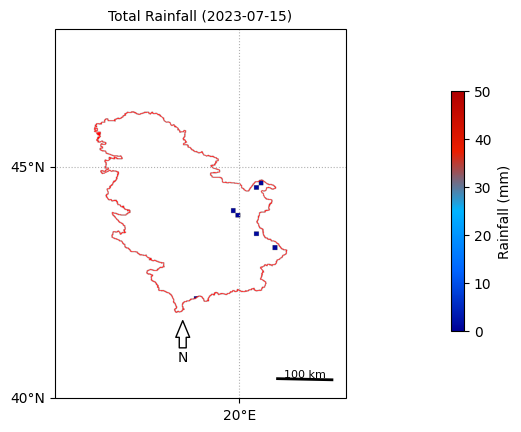

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import json

# import the cartoee functionality from geemap
from geemap import cartoee

# set the width and height of the map
w = 3
h = 4

# set the center of the map
lon = 21
lat = 44

region = serbia_with_kosovo_geometry.bounds().getInfo()['coordinates']
# set the region of interest
region = [lon - w, lat - h, lon + w, lat + h]


# use cartoee to get a map
ax = cartoee.get_map(image, region=region, vis_params=vis_params)

# add the Indonesia boundary to the map
outline_style = {"color": "FF0000", "width": 2, "fillColor": "00000000"}
cartoee.add_layer(
    ax, serbia.style(**outline_style), region=region, crs=ccrs.PlateCarree()
)

# add gridlines to the map at a specified interval
cartoee.add_gridlines(ax, interval=[5, 5], linestyle=":")

# add a colorbar to the map (right side)
cb = cartoee.add_colorbar(
    ax, vis_params, loc="right", label="Rainfall (mm)", orientation="vertical"
)

# add north arrow
north_arrow_dict = {
    "text": "N",
    "xy": (0.44, 0.21),
    "arrow_length": 0.10,
    "text_color": "black",
    "arrow_color": "white",
    "fontsize": 10,
    "width": 5,
    "headwidth": 10,
    "ha": "center",
    "va": "center",
}
cartoee.add_north_arrow(ax, **north_arrow_dict)

# add scale bar
scale_bar_dict = {
    "length": 100,
    "xy": (0.1, 0.05),
    "linewidth": 2,
    "fontsize": 8,
    "color": "black",
    "unit": "km",
    "ha": "center",
    "va": "bottom",
}
cartoee.add_scale_bar_lite(ax, **scale_bar_dict)

# add title
ax.set_title(label="Total Rainfall (2023-07-15)", fontsize=10)

plt.show()

In [ ]:
!pip install cartopy
import cartopy

In [ ]:
# create a gif of the images in the clipped collection
cartoee.get_image_collection_gif(
    ee_ic=clipped_imerg_collection,
    out_dir="./img/gif_images",
    out_gif="./img/animation_dva.gif",
    vis_params=vis_params,
    region=region,
    fps=2,
    mp4=True,
    grid_interval=(5, 5),
    plot_title="Serbia Daily Rainfall",
    date_format="YYYY-MM-dd:HH-mm",
    fig_size=(7, 7),
    dpi_plot=100,
    file_format="png",
    overlay_layers=[serbia_with_kosovo_geometry],
    overlay_styles=[outline_style],
    colorbar_dict={"loc": "right", "label": "Rainfall (mm)", "orientation": "vertical"},
    north_arrow_dict=north_arrow_dict,
    scale_bar_dict=scale_bar_dict,
    verbose=True,
)

GIF saved to /content/img/gif_images/img/animation_dva.gif
MP4 saved to /content/img/gif_images/img/animation_dva.mp4


In [ ]:
!1s /content

/bin/bash: line 1: 1s: command not found


In [ ]:
1s!

SyntaxError: invalid decimal literal (ipython-input-128644183.py, line 1)